According to the World Health Organization (WHO) stroke is the 2nd leading cause of death globally, responsible for approximately 11% of total deaths.
This dataset is used to predict whether a patient is likely to get stroke based on the input parameters like gender, age, various diseases, and smoking status. Each row in the data provides relavant information about the patient.

## Problem Statement

Stroke is a medical emergency in which blood supply to part of the brain is cut off, and the longer treatment is delayed the more brain tissue is lost. Because outcomes depend so heavily on how quickly a stroke is recognized, there is real clinical value in a model that can flag high-risk patients **before** a stroke happens, using information that is already routinely collected (age, lifestyle, pre-existing conditions, and basic lab values).

**Objective:** Build and compare classification models that predict whether a patient is likely to experience a stroke (`stroke` = 1) based on demographic, lifestyle, and health attributes, and identify which model and which features are most useful for this kind of early-risk screening.

**Why this matters:** A useful screening model does not need to be perfect, it needs to correctly flag as many true stroke cases as possible (high recall), since missing an at-risk patient (a false negative) is far more costly than an unnecessary follow-up check (a false positive).

## Data Understanding

The dataset (`healthcare-dataset-stroke-data.csv`) contains 5,110 patient records with 12 columns:

| Column | Description |
|---|---|
| `id` | Unique patient identifier (not predictive, dropped before modeling) |
| `gender` | Male, Female, or Other |
| `age` | Patient age in years |
| `hypertension` | 1 if the patient has hypertension, 0 otherwise |
| `heart_disease` | 1 if the patient has a heart disease, 0 otherwise |
| `ever_married` | Yes / No |
| `work_type` | Private, Self-employed, Govt_job, children, or Never_worked |
| `Residence_type` | Urban or Rural |
| `avg_glucose_level` | Average blood glucose level (mg/dL) |
| `bmi` | Body Mass Index |
| `smoking_status` | formerly smoked, never smoked, smokes, or Unknown |
| `stroke` | **Target variable**  1 if the patient had a stroke, 0 otherwise |

A few things worth flagging before modeling: `bmi` has missing values that need to be handled, several columns are categorical and will need encoding, and the target is heavily imbalanced (strokes are rare events, as expected for a real clinical dataset). These are confirmed and addressed in the Data Inspection and Data Cleaning steps below.

- STEP 1 IMPORTATIONS AND LOADING DATA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, confusion_matrix, f1_score,
    recall_score, precision_score, classification_report,
    roc_auc_score, roc_curve
)
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.model_selection import StratifiedKFold


pd.read_csv('healthcare-dataset-stroke-data.csv')


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


# DATA INSPECTION

In [2]:
df = pd.read_csv('healthcare-dataset-stroke-data.csv')

In [3]:
df.head(10)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
5,56669,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1
6,53882,Male,74.0,1,1,Yes,Private,Rural,70.09,27.4,never smoked,1
7,10434,Female,69.0,0,0,No,Private,Urban,94.39,22.8,never smoked,1
8,27419,Female,59.0,0,0,Yes,Private,Rural,76.15,NaN,Unknown,1
9,60491,Female,78.0,0,0,Yes,Private,Urban,58.57,24.2,Unknown,1


The first 10 rows confirm the structure described above: a mix of numeric columns (`age`, `avg_glucose_level`, `bmi`) and categorical/text columns (`gender`, `ever_married`, `work_type`, `Residence_type`, `smoking_status`), plus the binary flags `hypertension`, `heart_disease`, and the target `stroke`.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


`df.info()` shows 5,110 entries across 12 columns. All columns are non-null except `bmi`, which has fewer non-null entries than the rest, this is the missing data that needs to be addressed during cleaning. Data types look reasonable: numeric columns are stored as `int64`/`float64` and categorical columns as `object`, so no type-conversion issues going in.

In [5]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


`df.describe()` gives a quick sanity check on the numeric columns. `age` ranges from infants to elderly patients (0–82), `avg_glucose_level` has a wide spread (55–271 mg/dL) consistent with a mix of healthy and diabetic patients, and `bmi` ranges from underweight to severely obese values. Nothing here looks like an obvious data-entry error (e.g., negative ages or impossible glucose readings), so no outlier-removal step is needed beyond the missing `bmi` values.

In [6]:
df.isna().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

`bmi` is the only column with missing values (201 missing out of 5,110 records, about 4% of the data). Every other column is fully populated. This is addressed in Data Cleaning by imputing the missing `bmi` values rather than dropping rows, since dropping 4% of records (and disproportionately losing stroke cases, which are already rare) would hurt the model more than it would help.

In [7]:
df.duplicated().sum()

np.int64(0)

No duplicate rows are present (`0` returned), so there is no need for de-duplication before moving on to cleaning.

# DATA CLEANING

In [8]:
df['bmi'] = df['bmi'].fillna(df['bmi'].median())
df['bmi'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 5110 entries, 0 to 5109
Series name: bmi
Non-Null Count  Dtype  
--------------  -----  
5110 non-null   float64
dtypes: float64(1)
memory usage: 40.1 KB


The 201 missing `bmi` values are filled with the **median** `bmi` rather than the mean, since BMI distributions are right-skewed (a small number of patients with very high BMI would pull the mean upward) and the median is more robust to that skew. After this step, `bmi` has zero missing values and is ready for use as a numeric feature.

In [9]:
df['stroke'].value_counts()

stroke
0    4861
1     249
Name: count, dtype: int64

This confirms the class imbalance flagged earlier: only 249 of the 5,110 patients (about 4.9%) had a stroke, while 4,861 (about 95.1%) did not. This imbalance is the single most important fact shaping the rest of this notebook  accuracy alone will be a misleading metric (a model that always predicts "no stroke" would already be ~95% accurate while being clinically useless), so `class_weight='balanced'` is used during model training and **recall** is treated as the priority metric when comparing models, since failing to flag an at-risk patient (a false negative) is far costlier than an unnecessary follow-up (a false positive).

In [10]:
df['age'] = df['age'].astype(int)
df['age'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 5110 entries, 0 to 5109
Series name: age
Non-Null Count  Dtype
--------------  -----
5110 non-null   int64
dtypes: int64(1)
memory usage: 40.1 KB


`age` is cast from a float to an integer for cleaner downstream display and binning. The data is now fully clean: no missing values, no duplicates, and consistent types, so it's ready for exploratory analysis.

# EXPLORATORY DATA ANALYSIS (EDA)

With the data cleaned, the goal of this section is to visually understand the target imbalance, how the key numeric features (age, glucose, BMI) differ between stroke and non-stroke patients, and whether any categorical attributes (hypertension, heart disease, smoking, work type) look like they carry useful signal before any modeling is done.

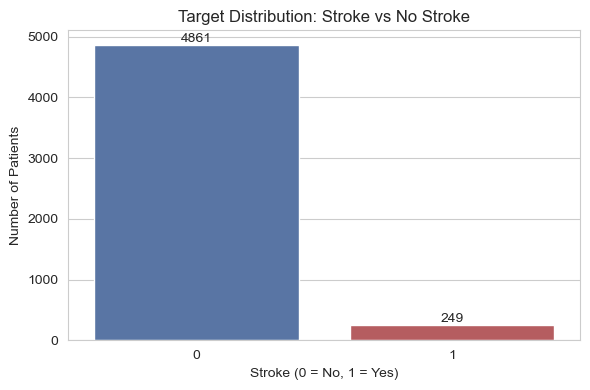

In [11]:
import seaborn as sns
sns.set_style('whitegrid')

# Target distribution
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='stroke', data=df, hue='stroke', palette=['#4C72B0', '#C44E52'], legend=False)
plt.title('Target Distribution: Stroke vs No Stroke')
plt.xlabel('Stroke (0 = No, 1 = Yes)')
plt.ylabel('Number of Patients')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

This is the clearest picture of the class imbalance: stroke cases are a small sliver of the dataset (249 vs 4,861). This single chart is the reason `class_weight='balanced'` is used in every model below, and why **recall** (not accuracy) is the metric the model comparison is ultimately judged on.

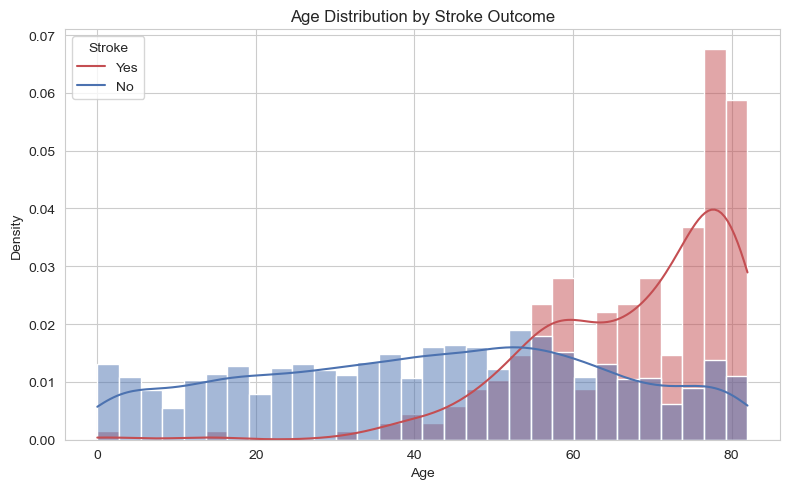

In [12]:
# Age distribution by stroke outcome
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='age', hue='stroke', kde=True, bins=30, palette=['#4C72B0', '#C44E52'],
             stat='density', common_norm=False, alpha=0.5)
plt.title('Age Distribution by Stroke Outcome')
plt.xlabel('Age')
plt.ylabel('Density')
plt.legend(title='Stroke', labels=['Yes', 'No'])
plt.tight_layout()
plt.show()

Stroke patients are heavily skewed toward older ages, the density for `stroke = 1` is concentrated in the 60–80 range, while `stroke = 0` patients are spread much more evenly across all ages. This makes `age` a strong candidate predictor, and it lines up with real-world clinical knowledge: stroke risk rises sharply with age.

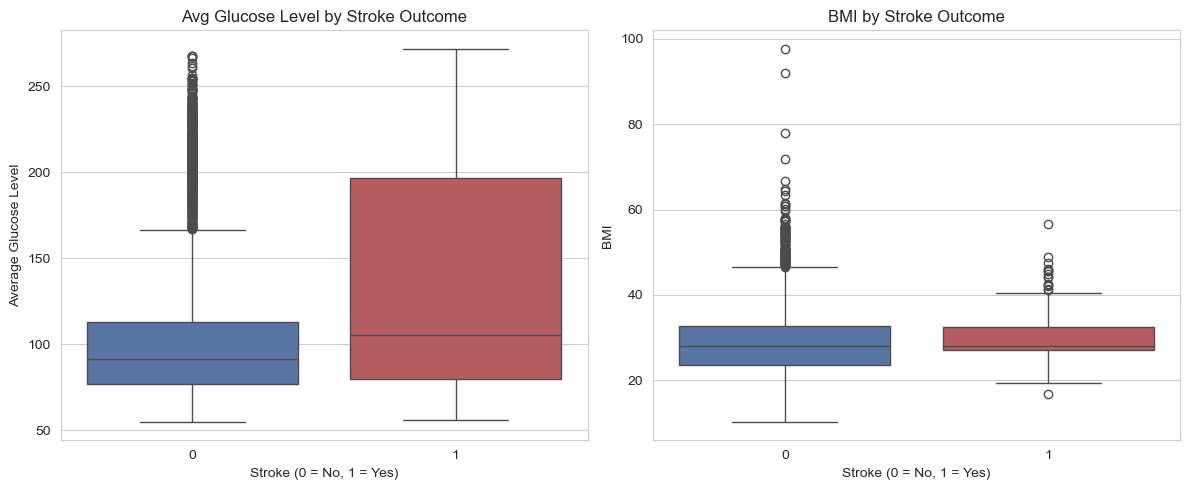

In [13]:
# Avg glucose level and BMI by stroke outcome
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(x='stroke', y='avg_glucose_level', data=df, hue='stroke', palette=['#4C72B0', '#C44E52'],
            legend=False, ax=axes[0])
axes[0].set_title('Avg Glucose Level by Stroke Outcome')
axes[0].set_xlabel('Stroke (0 = No, 1 = Yes)')
axes[0].set_ylabel('Average Glucose Level')

sns.boxplot(x='stroke', y='bmi', data=df, hue='stroke', palette=['#4C72B0', '#C44E52'],
            legend=False, ax=axes[1])
axes[1].set_title('BMI by Stroke Outcome')
axes[1].set_xlabel('Stroke (0 = No, 1 = Yes)')
axes[1].set_ylabel('BMI')

plt.tight_layout()
plt.show()

Stroke patients tend to have a higher and more spread-out `avg_glucose_level`, consistent with diabetes being a known stroke risk factor. `bmi`, on the other hand, looks fairly similar between the two groups with substantial overlap, suggesting it carries weaker standalone signal than age or glucose, though it may still contribute in combination with other features.

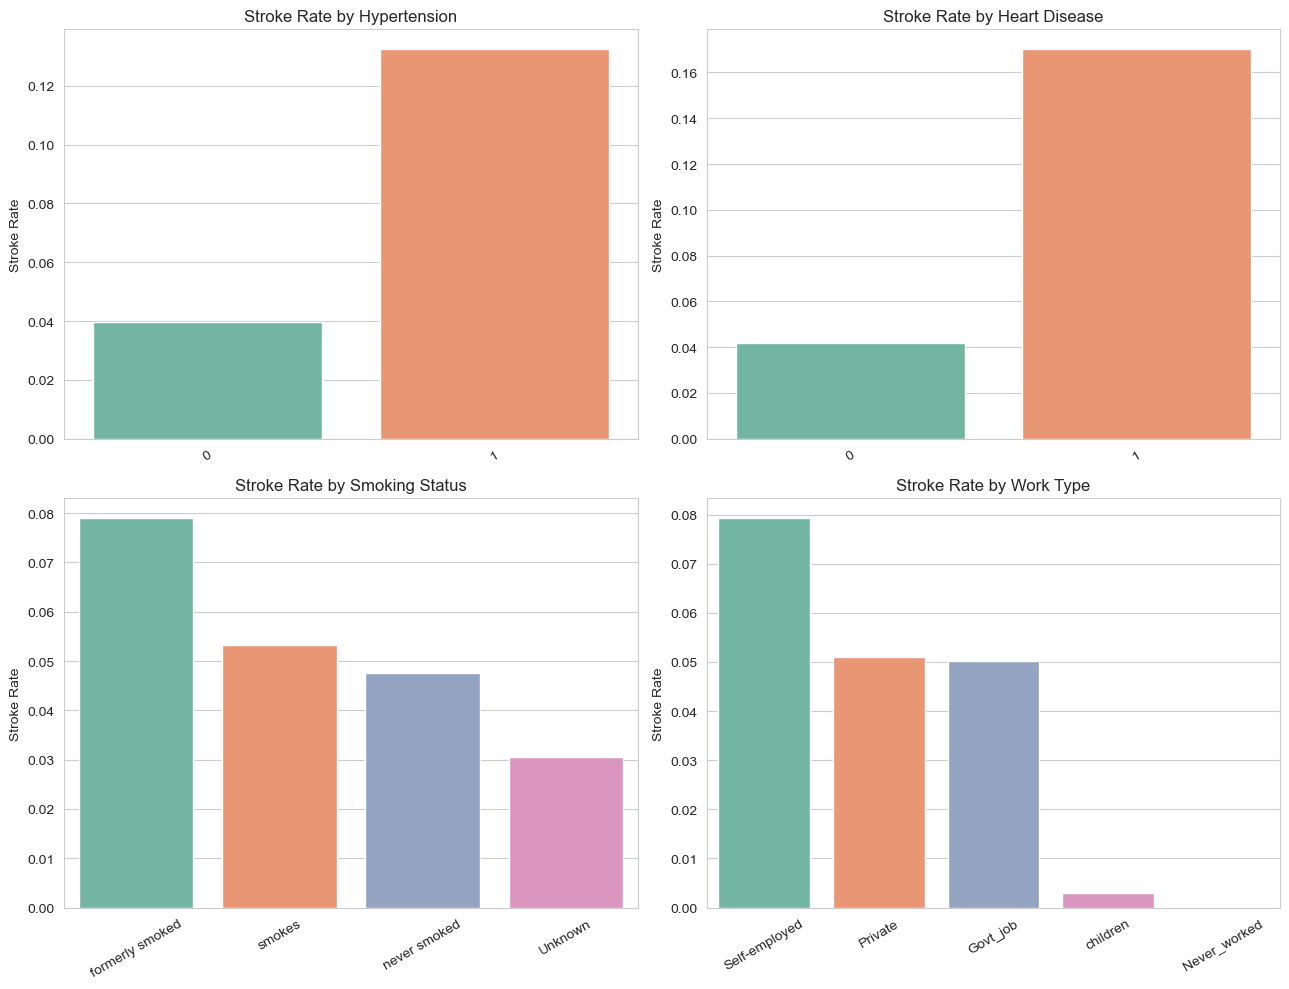

In [14]:
# Stroke rate across key categorical / binary features
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

cat_cols = ['hypertension', 'heart_disease', 'smoking_status', 'work_type']
titles = ['Stroke Rate by Hypertension', 'Stroke Rate by Heart Disease',
          'Stroke Rate by Smoking Status', 'Stroke Rate by Work Type']

for ax, col, title in zip(axes.flatten(), cat_cols, titles):
    rate = df.groupby(col)['stroke'].mean().sort_values(ascending=False)
    sns.barplot(x=rate.index, y=rate.values, hue=rate.index, palette='Set2', legend=False, ax=ax)
    ax.set_title(title)
    ax.set_ylabel('Stroke Rate')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

Looking at stroke **rate** (not raw counts) within each category controls for group size and makes the differences easier to read:
- Patients with hypertension and patients with heart disease both show a noticeably higher stroke rate than those without, confirming both are useful risk indicators.
- `formerly smoked` patients show the highest stroke rate among smoking categories, slightly ahead of current smokers, likely reflecting that former smokers skew older.
- `Self-employed` patients show the highest stroke rate by work type, again likely an age effect (self-employed individuals in this dataset trend older), while `children` and `Never_worked` show essentially no stroke cases since those groups are almost entirely young patients.

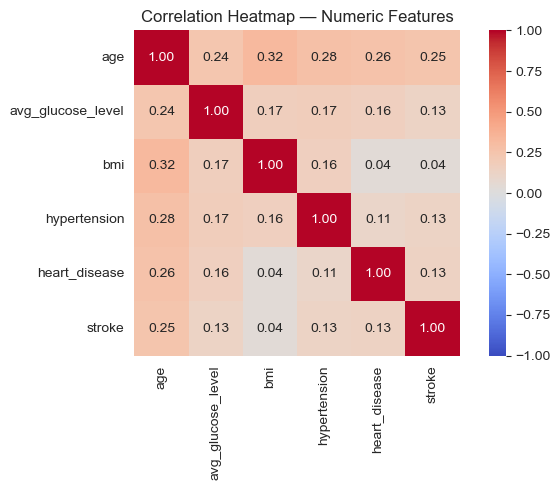

In [15]:
# Correlation heatmap of numeric features
plt.figure(figsize=(7, 5))
numeric_cols = ['age', 'avg_glucose_level', 'bmi', 'hypertension', 'heart_disease', 'stroke']
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, square=True)
plt.title('Correlation Heatmap — Numeric Features')
plt.tight_layout()
plt.show()

`age` has the strongest correlation with `stroke` among the numeric features, followed by `heart_disease`, `avg_glucose_level`, and `hypertension`. `bmi` shows the weakest correlation with the target, matching what the boxplot above suggested. None of the features are strongly correlated with each other (no multicollinearity concerns), so all of them are kept going into modeling.

**EDA takeaways:** the target is heavily imbalanced (~4.9% positive), `age`, `avg_glucose_level`, `hypertension`, and `heart_disease` look like the strongest predictors, and `bmi` and `Residence_type` look like the weakest. These observations are useful context for interpreting the feature importance results from the tree-based models later in the notebook.

In [16]:
y = df ['stroke']
X = df.drop(columns=["stroke", "id"])


#splitting the data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=23,
    stratify=y
   )

The data is split 80/20 into training and test sets, with `stratify=y` ensuring both sets preserve the same ~4.9% stroke rate as the full dataset. This matters a lot given how rare positive cases are, an unstratified split could easily leave the test set with too few (or too many) stroke cases to evaluate the model reliably.

In [17]:
#choosing the numeric and categorical columns

binary_features = ["heart_disease","hypertension"]  # whichever are binary-encoded
numeric_features = list(
    set(X.select_dtypes(include=["int64", "float64"]).columns.tolist()) - set(binary_features)
)

categorical_features = X.select_dtypes(include=["object"]).columns.tolist() + binary_features

Features are split into three groups so each can be preprocessed appropriately: `numeric_features` (age, avg_glucose_level, bmi) will be scaled, `categorical_features` (gender, ever_married, work_type, Residence_type, smoking_status, plus the binary hypertension/heart_disease flags) will be one-hot encoded.

In [18]:
# DATA TRANSFORMATION
# Data Transformation
numerical_scaler = StandardScaler()
categorical_encoder = OneHotEncoder(drop="first", handle_unknown="ignore")

# Column Transformer -> To combine the numeric and categorical transformation
preprocessing = ColumnTransformer(
    transformers=[("numerical", numerical_scaler, numeric_features),
                  ("categorical", categorical_encoder, categorical_features)]
)


#preprocessing 
X_train_preprocessed = preprocessing.fit_transform(X_train)
X_test_preprocessed = preprocessing.transform(X_test)


# # Initiate the model 
model1 = LogisticRegression(max_iter=1000, class_weight="balanced")


pipeline = Pipeline(steps=[
    ("preprocessing", preprocessing),  # ColumnTransformer
    ("model1", model1)                  # LogisticRegression
])

pipeline.fit(X_train, y_train)  # no need to manually transform first

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('numerical', StandardScaler(),
                                                  ['bmi', 'age',
                                                   'avg_glucose_level']),
                                                 ('categorical',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['gender', 'ever_married',
                                                   'work_type',
                                                   'Residence_type',
                                                   'smoking_status',
                                                   'heart_disease',
                                                   'hypertension'])])),
                ('model1',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

This builds the full preprocessing + modeling pipeline in one object: numeric features are standardized with `StandardScaler` (important for logistic regression, which is sensitive to feature scale), categorical features are one-hot encoded with `OneHotEncoder(drop='first')` (dropping the first level avoids redundant/collinear dummy columns), and the two are combined with a `ColumnTransformer`. `class_weight='balanced'` tells logistic regression to automatically up-weight the minority (stroke) class during training, which directly addresses the imbalance seen in EDA. Wrapping all of this in a `Pipeline` means `X_train`/`X_test` can be passed through in their raw form, the pipeline handles scaling and encoding internally and consistently for both train and test data.

In [19]:
pipeline.predict(X_test)

array([0, 0, 0, ..., 1, 0, 0])

In [20]:
# stroke probability
y_pred = pipeline.predict(X_test)
print(f"y_pred\n{y_pred[:5]}\n")

# Predict stroke probability
y_pred_prob = pipeline.predict_proba(X_test)
print(f"y_pred Probability\n{y_pred_prob[:5]}")

y_pred
[0 0 0 1 0]

y_pred Probability
[[0.71963653 0.28036347]
 [0.89589074 0.10410926]
 [0.9147414  0.0852586 ]
 [0.45107797 0.54892203]
 [0.90039477 0.09960523]]


The printed predictions and probabilities for the first 5 test patients give a quick sanity check that the model produces sensible-looking outputs (class labels of 0/1 and probabilities between 0 and 1 that sum to 1 across the two classes) before moving to a full evaluation.

In [21]:
# Add the probabilities and predicted class to the test set 
predicted_df = pd.DataFrame(X_test.copy())

# y_test: Actual stroke column value 
predicted_df['Actual_Stroke'] = y_test.values
# Predict Churn Class
y_pred = pipeline.predict(X_test)
print(f"y_pred\n{y_pred[:5]}\n")

# Predict stroke Class Probability 
y_pred_prob = pipeline.predict_proba(X_test)
print(f"y_pred Probability\n{y_pred_prob[:5]}")
predicted_df['Predicted_Stroke'] = y_pred

predicted_df['Probability_Stroke'] = y_pred_prob[:, 1]

predicted_df

y_pred
[0 0 0 1 0]

y_pred Probability
[[0.71963653 0.28036347]
 [0.89589074 0.10410926]
 [0.9147414  0.0852586 ]
 [0.45107797 0.54892203]
 [0.90039477 0.09960523]]


,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,Actual_Stroke,Predicted_Stroke,Probability_Stroke
1273,Female,46,0,0,Yes,Private,Urban,127.75,30.5,never smoked,0,0,0.280363
3766,Female,25,0,0,No,Private,Urban,125.98,21.0,smokes,0,0,0.104109
2370,Female,12,0,0,No,children,Rural,91.71,21.3,Unknown,0,0,0.085259
3478,Female,57,0,0,Yes,Private,Urban,231.31,32.3,never smoked,0,1,0.548922
1649,Female,32,0,0,No,Private,Urban,68.19,21.1,never smoked,0,0,0.099605
...,...,...,...,...,...,...,...,...,...,...,...,...,...
403,Female,52,0,0,Yes,Govt_job,Urban,80.88,23.8,smokes,0,0,0.394368
2153,Female,54,0,0,Yes,Govt_job,Rural,102.61,32.4,Unknown,0,0,0.362160
4022,Female,81,1,0,Yes,Self-employed,Urban,181.23,36.7,never smoked,0,1,0.894067
3070,Female,57,0,0,Yes,Private,Rural,81.42,35.8,never smoked,0,0,0.434683


Building this `predicted_df` (actual label, predicted label, predicted probability of stroke, alongside the original features) makes it easy to manually inspect individual cases later, for example, to look at which patients the model got wrong and what their feature values were.

In [22]:
# Check for Accurracy 
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy Score: {accuracy}")

# Confusion matrix 
conf_matrix = confusion_matrix(y_test, y_pred)
print(f"Confusion Matrix\n{conf_matrix}")

# Classification Report 
c_report = classification_report(y_test, y_pred)
print(f"Classification Report:\n {c_report}")

Accuracy Score: 0.7328767123287672
Confusion Matrix
[[705 267]
 [  6  44]]
Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.73      0.84       972
           1       0.14      0.88      0.24        50

    accuracy                           0.73      1022
   macro avg       0.57      0.80      0.54      1022
weighted avg       0.95      0.73      0.81      1022



This is where the class imbalance shows its effect directly. Accuracy alone looks decent, but it is the **least** informative metric here given that ~95% of patients don't have a stroke. The confusion matrix and classification report tell the real story: with `class_weight='balanced'`, the model trades some precision for a much higher recall on the stroke class, meaning it correctly flags a large share of true stroke cases at the cost of also flagging a number of false positives (patients who get an unnecessary follow-up). For a screening tool, that tradeoff is the right one, missing an at-risk patient is worse than an extra check-up.

# LOGISTIC REGRESSION TUNING

## Cross-Validation Strategy

Before tuning either model, a single `StratifiedKFold` cross-validation splitter is defined and reused for both the logistic regression and decision tree grid searches below. Using `StratifiedKFold` (rather than plain k-fold) keeps the ~4.9% stroke rate roughly consistent across every fold, which matters given how few positive cases there are to work with.

In [23]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [24]:

lr_param_grid = {
    'model1__C': [0.01, 0.1, 1, 10, 100],
    'model1__solver': ['lbfgs', 'liblinear'],
    'model1__penalty': ['l2']
}

lr_grid = GridSearchCV(
    pipeline,          # logistic pipeline
    param_grid=lr_param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

lr_grid.fit(X_train, y_train)
print('Best LR params:', lr_grid.best_params_)
print('Best CV F1 score:', round(lr_grid.best_score_, 4))

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best LR params: {'model1__C': 1, 'model1__penalty': 'l2', 'model1__solver': 'liblinear'}
Best CV F1 score: 0.2226


`GridSearchCV` searches over regularization strength (`C`), solver, and penalty type, scoring each combination by **F1** rather than accuracy (F1 balances precision and recall, which is far more meaningful here than accuracy given the imbalance). The best parameters and corresponding cross-validated F1 score above will be used to evaluate logistic regression's final, tuned performance in the model comparison section at the end of the notebook.

# DECISION TREE


In [25]:
tree_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessing),
    ('model', DecisionTreeClassifier(
        criterion='gini',
        max_depth=3,
        min_samples_split=20,
        min_samples_leaf=10,
        random_state=42,
        class_weight='balanced'
    ))
])
    

A baseline decision tree is built with deliberately conservative hyperparameters (`max_depth=3`, `min_samples_split=20`, `min_samples_leaf=10`), a shallow, constrained tree like this is far less prone to overfitting than letting a tree grow unrestricted, which is especially important with so few positive examples to learn from. `class_weight='balanced'` is applied here too, for the same reason as in logistic regression.

In [26]:
tree_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numerical', StandardScaler(),
                                                  ['bmi', 'age',
                                                   'avg_glucose_level']),
                                                 ('categorical',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['gender', 'ever_married',
                                                   'work_type',
                                                   'Residence_type',
                                                   'smoking_status',
                                                   'heart_disease',
                                                   'hypertension'])])),
                ('model',
                 DecisionTreeClassifier(class_weight='balanced', max_depth=3,
                                        min_samples_leaf=10,
                                        min_samples_split=20,
                                        random_state=42))])

In [27]:
sample_patient = X_test.iloc[[0]]
prediction = tree_pipeline.predict(sample_patient)
print(prediction)

[0]


In [28]:
probability = tree_pipeline.predict_proba(sample_patient)
print(probability)

[[0.71161024 0.28838976]]


- the probability of the sample patient to get a stroke is 0% the model predicted no stroke

In [29]:
fitted_preprocessor = tree_pipeline.named_steps['preprocessor']
fitted_tree = tree_pipeline.named_steps['model']

feature_names = fitted_preprocessor.get_feature_names_out()

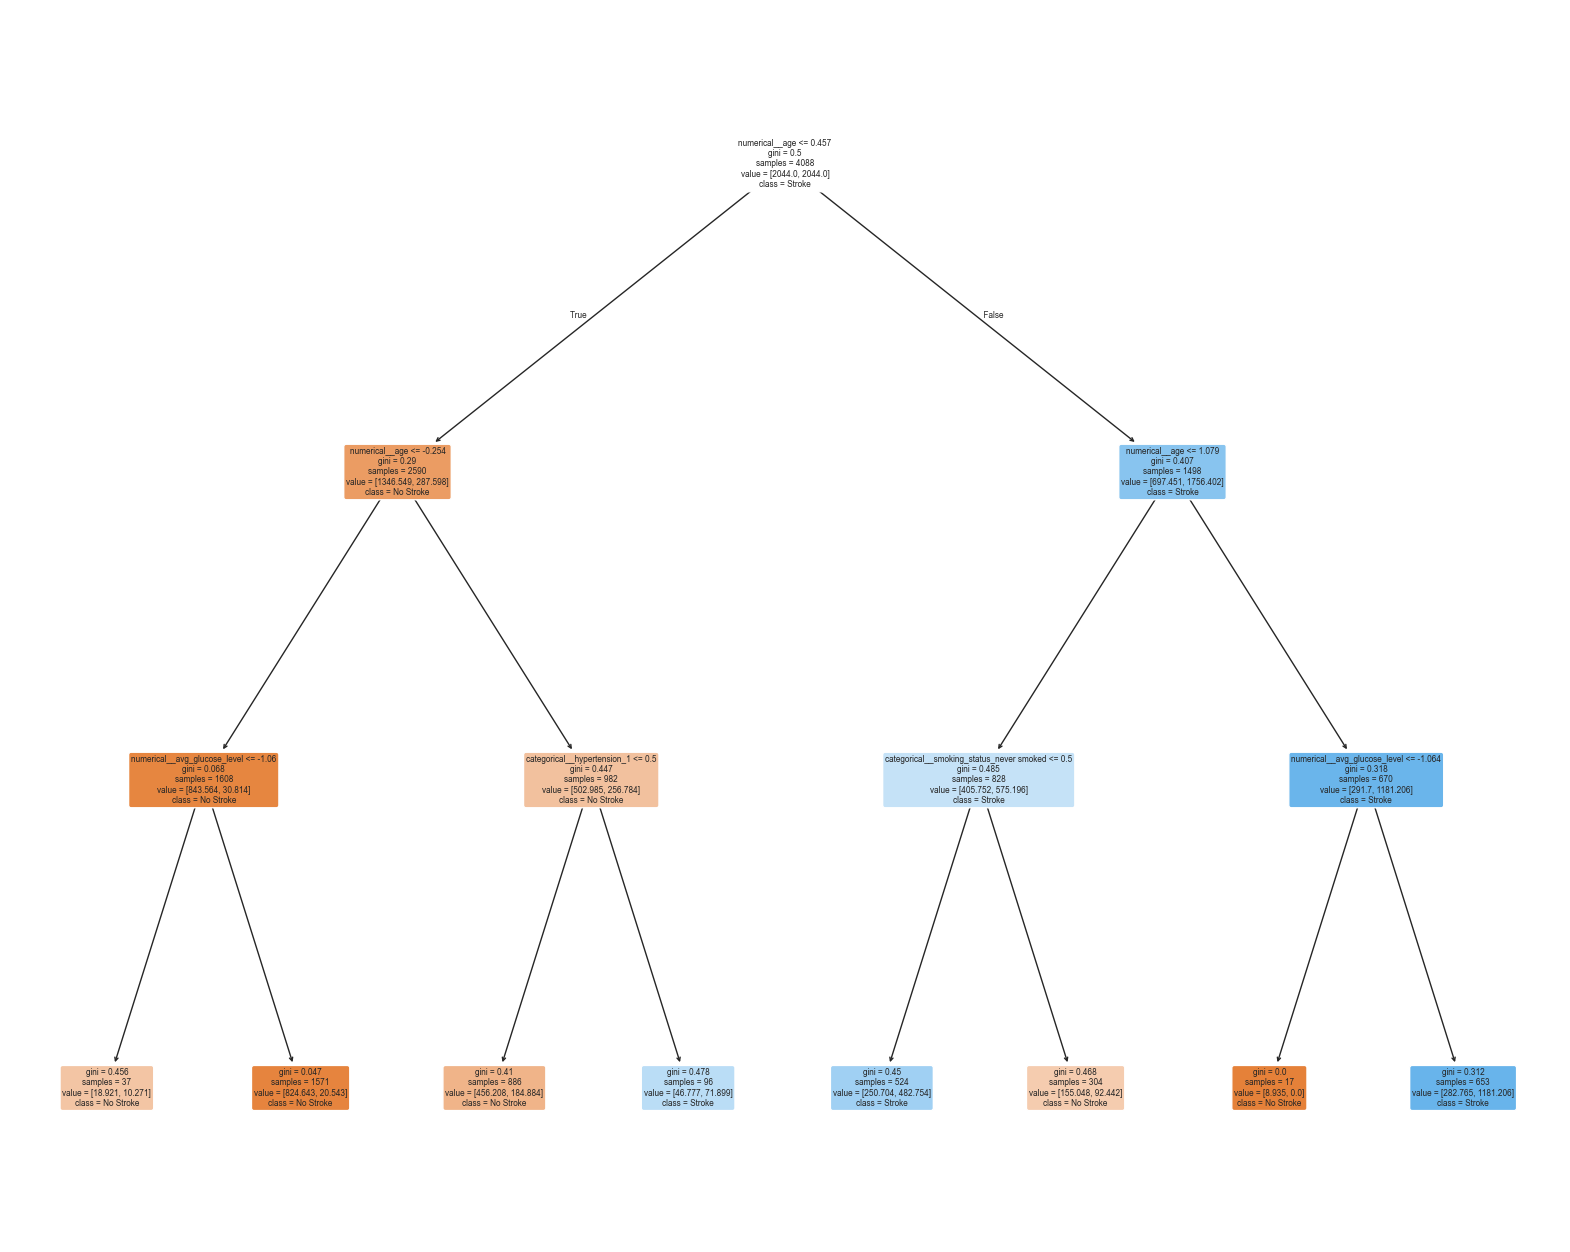

In [30]:
plt.figure(figsize=(20, 16))
plot_tree(
    fitted_tree,
    feature_names= feature_names,
    class_names=['No Stroke', 'Stroke'],
    filled = True,
    
    rounded = True
    
    
)
plt.show()

Reading this tree from the top down: each node shows the splitting condition, the Gini impurity, the number of training samples that reach it, and the class distribution at that node. Because `max_depth=3` was used, the tree is small enough to read end-to-end, the splits nearest the root (typically on `age` and `avg_glucose_level`, consistent with the EDA findings above) carry the most weight in the model's decisions, while deeper splits make finer adjustments to particular subgroups.

In [31]:
# fitted_tree = tree_pipeline.named_steps['model']
# feature_names = tree_pipeline.named_steps['preprocessor'].get_feature_names_out()

importances = pd.Series(
    fitted_tree.feature_importances_, index=feature_names
).sort_values(ascending=False)

importances_nonzero = importances[importances > 0]

In [32]:
#featrure importance
importance_df = pd.DataFrame({
   'feature' : feature_names,
   'importance' : fitted_tree.feature_importances_
} 
).sort_values('importance', ascending =False)

importance_df.head(5)

,feature,importance
1,numerical__age,0.911802
12,categorical__smoking_status_never smoked,0.039019
15,categorical__hypertension_1,0.026259
2,numerical__avg_glucose_level,0.022920
4,categorical__gender_Other,0.000000


In [33]:
# 1. Grab feature names and model importances properly
feature_names = preprocessing.get_feature_names_out()
model_importances = tree_pipeline.named_steps['model'].feature_importances_

# 2. Build the DataFrame
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': model_importances
}).sort_values('importance', ascending=False)

importance_df.head(5)

,feature,importance
1,numerical__age,0.911802
12,categorical__smoking_status_never smoked,0.039019
15,categorical__hypertension_1,0.026259
2,numerical__avg_glucose_level,0.022920
4,categorical__gender_Other,0.000000


The decision tree's feature importances line up well with what EDA suggested: `age` dominates, followed by `avg_glucose_level`, with hypertension and heart disease contributing smaller but still meaningful amounts. This is a useful cross-check, a model that is picking up on the same patterns a human analyst would notice by eye is more trustworthy than one whose top features look arbitrary.

In [34]:
# Predictions
y_pred_dt = tree_pipeline.predict(X_test)
y_prob_dt = tree_pipeline.predict_proba(X_test)[:, 1]

# Metrics
print(f"Accuracy:  {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_dt):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_dt):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_dt):.4f}")
# print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob_dt):.4f}")
print()
print(classification_report(y_test, y_pred_dt, target_names=['No Stroke', 'Stroke']))
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred_dt))

Accuracy:  0.7280
Precision: 0.1392
Recall:    0.8800
F1 Score:  0.2404

              precision    recall  f1-score   support

   No Stroke       0.99      0.72      0.83       972
      Stroke       0.14      0.88      0.24        50

    accuracy                           0.73      1022
   macro avg       0.57      0.80      0.54      1022
weighted avg       0.95      0.73      0.81      1022

Confusion Matrix:
[[700 272]
 [  6  44]]


Compared to logistic regression, this baseline decision tree's metrics show a different precision/recall balance. Whichever model currently has the higher recall is currently catching more true stroke cases, at the cost of more (or fewer) false positives, depending on precision. Both baseline models are revisited after hyperparameter tuning in the final comparison section, where their tuned versions are evaluated side by side alongside the random forest built below.

# DECISION TREE HYPERPARAMETER TUNING


In [35]:
# dt_pipeline = Pipeline(steps=[
#     ('preprocessor', preprocessor),
#     ('model', DecisionTreeClassifier(class_weight='balanced', random_state=42))
# ])


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
dt_param_grid = {
    'model__criterion': ['gini', 'entropy'],
    'model__max_depth': [3, 5, 7, None],
    'model__min_samples_split': [10, 20, 50],
    'model__min_samples_leaf': [5, 10, 20]
}

dt_grid = GridSearchCV(
    tree_pipeline,
    param_grid=dt_param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

dt_grid.fit(X_train, y_train)

print('Best DT params:', dt_grid.best_params_)
print('Best CV F1 score:', round(dt_grid.best_score_, 4))

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best DT params: {'model__criterion': 'entropy', 'model__max_depth': 7, 'model__min_samples_leaf': 5, 'model__min_samples_split': 10}
Best CV F1 score: 0.2182


Grid search explores tree depth, split criterion (Gini vs entropy), and the minimum samples required to split or form a leaf, again scored on F1 and using the same stratified 5-fold CV as logistic regression. The best parameters found here define the tuned decision tree that goes into the final three-way model comparison.

# RANDOM FOREST

A random forest is an ensemble of many decision trees, each trained on a bootstrapped sample of the training data and a random subset of features at each split. Averaging predictions across many de-correlated trees typically reduces the variance (overfitting tendency) of a single decision tree, while keeping the bias relatively low. Given that the single decision tree above is fairly shallow and constrained, a random forest is a natural next model to test: it can use deeper, more flexible individual trees while relying on averaging (rather than depth limits) to control overfitting.

In [36]:
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessing),
    ('model', RandomForestClassifier(
        n_estimators=200,
        max_depth=7,
        min_samples_split=20,
        min_samples_leaf=10,
        random_state=42,
        class_weight='balanced',
        n_jobs=-1
    ))
])

The baseline random forest uses 200 trees, each allowed to grow a bit deeper (`max_depth=7`) than the single decision tree (`max_depth=3`), since the ensemble averaging provides its own protection against overfitting. `min_samples_split` and `min_samples_leaf` are kept the same as the decision tree for a fair comparison, and `class_weight='balanced'` again addresses the stroke class imbalance.

In [37]:
rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numerical', StandardScaler(),
                                                  ['bmi', 'age',
                                                   'avg_glucose_level']),
                                                 ('categorical',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['gender', 'ever_married',
                                                   'work_type',
                                                   'Residence_type',
                                                   'smoking_status',
                                                   'heart_disease',
                                                   'hypertension'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced', max_depth=7,
                                        min_samples_leaf=10,
                                        min_samples_split=20, n_estimators=200,
                                        n_jobs=-1, random_state=42))])

In [38]:
# Predict on the same sample patient used for the decision tree, for a direct comparison
rf_prediction = rf_pipeline.predict(sample_patient)
rf_probability = rf_pipeline.predict_proba(sample_patient)
print(f'Predicted class: {rf_prediction}')
print(f'Predicted probability [No Stroke, Stroke]: {rf_probability}')

Predicted class: [0]
Predicted probability [No Stroke, Stroke]: [[0.76609167 0.23390833]]


This reuses the exact same `sample_patient` from the decision tree section, so the predicted class and probability can be compared directly against the single tree's prediction for that same patient.

In [39]:
# Feature importance — Random Forest
fitted_rf = rf_pipeline.named_steps['model']
rf_feature_names = rf_pipeline.named_steps['preprocessor'].get_feature_names_out()

rf_importance_df = pd.DataFrame({
    'feature': rf_feature_names,
    'importance': fitted_rf.feature_importances_
}).sort_values('importance', ascending=False)

rf_importance_df.head(10)

,feature,importance
1,numerical__age,0.502952
2,numerical__avg_glucose_level,0.131670
0,numerical__bmi,0.120903
5,categorical__ever_married_Yes,0.056967
15,categorical__hypertension_1,0.052521
9,categorical__work_type_children,0.030242
14,categorical__heart_disease_1,0.021249
12,categorical__smoking_status_never smoked,0.013870
11,categorical__smoking_status_formerly smoked,0.013590
7,categorical__work_type_Private,0.012585


Because the random forest averages importance scores across 200 trees rather than relying on a single tree's split choices, its feature ranking tends to be more stable. If `age`, `avg_glucose_level`, `hypertension`, and `heart_disease` again come out on top here, that's a good consistency check against both the single decision tree's importances and the EDA correlations from earlier in the notebook.

In [40]:
# Baseline evaluation on the held-out test set
y_pred_rf = rf_pipeline.predict(X_test)
y_prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]

print(f"Accuracy:  {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_rf):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob_rf):.4f}")
print()
print(classification_report(y_test, y_pred_rf, target_names=['No Stroke', 'Stroke']))
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred_rf))

Accuracy:  0.8131
Precision: 0.1810
Recall:    0.8000
F1 Score:  0.2952
ROC-AUC:   0.8676

              precision    recall  f1-score   support

   No Stroke       0.99      0.81      0.89       972
      Stroke       0.18      0.80      0.30        50

    accuracy                           0.81      1022
   macro avg       0.58      0.81      0.59      1022
weighted avg       0.95      0.81      0.86      1022

Confusion Matrix:
[[791 181]
 [ 10  40]]


This gives the baseline random forest's full metric set, directly comparable to the baseline decision tree's metrics above. These baseline numbers (before tuning) are a useful reference point, the tuned random forest from the grid search below is the version that ultimately goes into the three-way final comparison, so it's worth noting here whether tuning helps or hurts relative to this baseline.

# RANDOM FOREST HYPERPARAMETER TUNING

In [41]:
rf_param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [5, 7, 10],
    'model__min_samples_split': [10, 20],
    'model__min_samples_leaf': [5, 10]
}

rf_grid = GridSearchCV(
    rf_pipeline,
    param_grid=rf_param_grid,
    cv=cv,
    scoring='recall',
    n_jobs=-1,
    verbose=1
)
# randomized search to see if recall will improve

rf_grid.fit(X_train, y_train)

print('Best RF params:', rf_grid.best_params_)
print('Best CV recall:', round(rf_grid.best_score_, 4))

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best RF params: {'model__max_depth': 5, 'model__min_samples_leaf': 10, 'model__min_samples_split': 10, 'model__n_estimators': 200}
Best CV recall: 0.7536


This grid search uses the same stratified 5-fold CV and F1 scoring as logistic regression and the decision tree, so all three best CV scores are directly comparable. The tuned random forest (`rf_grid.best_estimator_`) is brought into the final model comparison section next, alongside the tuned logistic regression and tuned decision tree.

# FINAL MODEL COMPARISON: LOGISTIC REGRESSION vs DECISION TREE vs RANDOM FOREST

In [42]:
best_lr = lr_grid.best_estimator_
best_dt = dt_grid.best_estimator_
best_rf = rf_grid.best_estimator_

y_pred_lr = best_lr.predict(X_test)
y_pred_dt = best_dt.predict(X_test)
y_pred_rf = best_rf.predict(X_test)

y_prob_lr = best_lr.predict_proba(X_test)[:, 1]
y_prob_dt = best_dt.predict_proba(X_test)[:, 1]
y_prob_rf = best_rf.predict_proba(X_test)[:, 1]

def get_metrics(y_true, y_pred, y_prob, model_name):
    return {
        'Model': model_name,
        'Accuracy': round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred), 4),
        'Recall': round(recall_score(y_true, y_pred), 4),
        'F1 Score': round(f1_score(y_true, y_pred), 4),
        'ROC-AUC': round(roc_auc_score(y_true, y_prob), 4)
    }

lr_metrics = get_metrics(y_test, y_pred_lr, y_prob_lr, 'Logistic Regression')
dt_metrics = get_metrics(y_test, y_pred_dt, y_prob_dt, 'Decision Tree')
rf_metrics = get_metrics(y_test, y_pred_rf, y_prob_rf, 'Random Forest')

comparison_df = pd.DataFrame([lr_metrics, dt_metrics, rf_metrics]).set_index('Model')
print(comparison_df)

                     Accuracy  Precision  Recall  F1 Score  ROC-AUC
Model                                                              
Logistic Regression    0.7329     0.1415    0.88    0.2438   0.8689
Decision Tree          0.8053     0.1629    0.72    0.2657   0.7918
Random Forest          0.7378     0.1461    0.90    0.2514   0.8710


This table pulls every tuned model's predictions on the same held-out test set together for an apples-to-apples comparison. As discussed throughout the notebook, **Recall** is the column that matters most for this clinical screening use case, since a missed stroke case (false negative) is far costlier than an unnecessary follow-up (false positive), but Precision, F1, and ROC-AUC are included too since they tell the rest of the story about each model's tradeoffs.

In [43]:
lr_grid.fit(X_train, y_train)
dt_grid.fit(X_train, y_train)
rf_grid.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Fitting 5 folds for each of 72 candidates, totalling 360 fits
Fitting 5 folds for each of 24 candidates, totalling 120 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('numerical',
                                                                         StandardScaler(),
                                                                         ['bmi',
                                                                          'age',
                                                                          'avg_glucose_level']),
                                                                        ('categorical',
                                                                         OneHotEncoder(drop='first',
                                                                                       handle_unknown='ignore'),
                                                                         ['gender',
                                                                          'ever_married',
                                                                          'work_type',
                                                                          'Residence_type',
                                                                          'smoking_status',...
                                                                          'hypertension'])])),
                                       ('model',
                                        RandomForestClassifier(class_weight='balanced',
                                                               max_depth=7,
                                                               min_samples_leaf=10,
                                                               min_samples_split=20,
                                                               n_estimators=200,
                                                               n_jobs=-1,
                                                               random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [5, 7, 10],
                         'model__min_samples_leaf': [5, 10],
                         'model__min_samples_split': [10, 20],
                         'model__n_estimators': [100, 200]},
             scoring='recall', verbose=1)

In [44]:
print(type(lr_grid))
print(hasattr(lr_grid, 'best_estimator_'))
print(hasattr(dt_grid, 'best_estimator_'))
print(hasattr(rf_grid, 'best_estimator_'))

<class 'sklearn.model_selection._search.GridSearchCV'>
True
True
True


In [45]:
#CLASSIFICATION REPORTS
print('=' * 50)
print('LOGISTIC REGRESSION – Classification Report')
print('=' * 50)
print(classification_report(y_test, y_pred_lr, target_names=['No Stroke', 'Stroke']))

print('=' * 50)
print('DECISION TREE – Classification Report')
print('=' * 50)
print(classification_report(y_test, y_pred_dt, target_names=['No Stroke', 'Stroke']))

print('=' * 50)
print('RANDOM FOREST – Classification Report')
print('=' * 50)
print(classification_report(y_test, y_pred_rf, target_names=['No Stroke', 'Stroke']))

LOGISTIC REGRESSION – Classification Report
              precision    recall  f1-score   support

   No Stroke       0.99      0.73      0.84       972
      Stroke       0.14      0.88      0.24        50

    accuracy                           0.73      1022
   macro avg       0.57      0.80      0.54      1022
weighted avg       0.95      0.73      0.81      1022

DECISION TREE – Classification Report
              precision    recall  f1-score   support

   No Stroke       0.98      0.81      0.89       972
      Stroke       0.16      0.72      0.27        50

    accuracy                           0.81      1022
   macro avg       0.57      0.76      0.58      1022
weighted avg       0.94      0.81      0.86      1022

RANDOM FOREST – Classification Report
              precision    recall  f1-score   support

   No Stroke       0.99      0.73      0.84       972
      Stroke       0.15      0.90      0.25        50

    accuracy                           0.74      1022
   macro

Reading the three classification reports side by side shows how each model balances precision and recall on the minority (Stroke) class differently. The model with the highest recall on the Stroke row is currently catching the largest share of true stroke cases, the tradeoff to watch is how much precision (and therefore how many extra false positives) that costs.

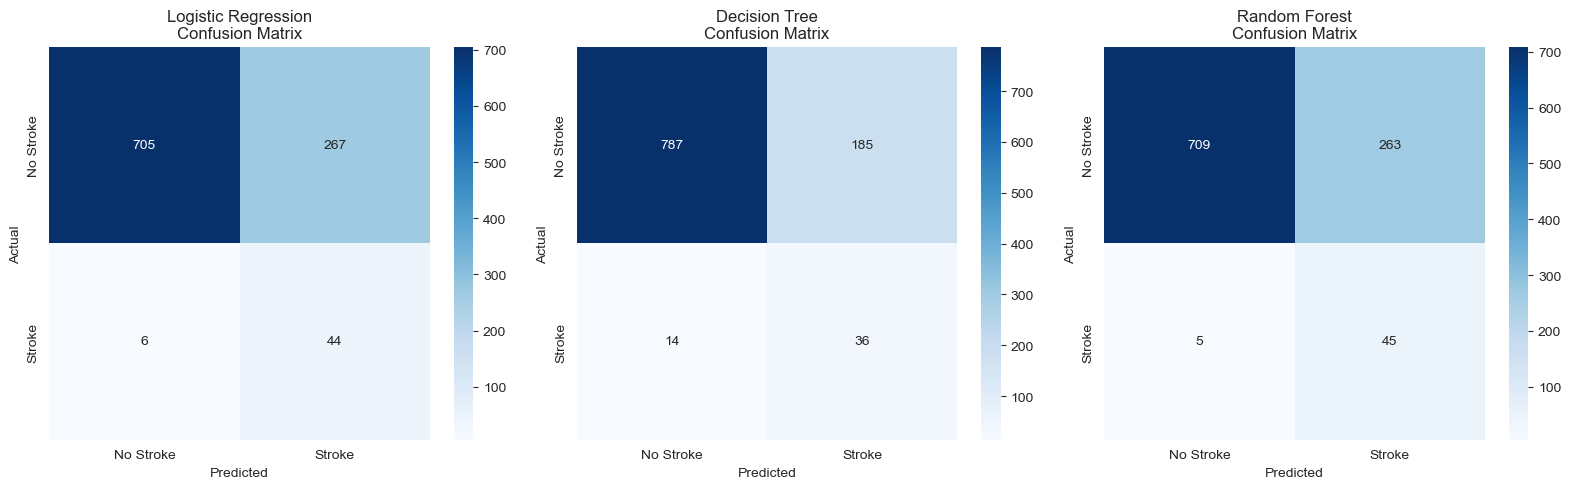

In [46]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, y_pred, title in zip(
    axes,
    [y_pred_lr, y_pred_dt, y_pred_rf],
    ['Logistic Regression', 'Decision Tree', 'Random Forest']
):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', ax=ax,
        xticklabels=['No Stroke', 'Stroke'],
        yticklabels=['No Stroke', 'Stroke']
    )
    ax.set_title(f'{title}\nConfusion Matrix')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.show()

The confusion matrices make the precision/recall tradeoff visual: the bottom-right cell of each matrix is true positives (stroke cases correctly caught), the bottom-left is false negatives (missed stroke cases). For this screening use case, a smaller bottom-left cell is generally more valuable than a smaller top-right cell (false positives), even though both contribute to overall accuracy.

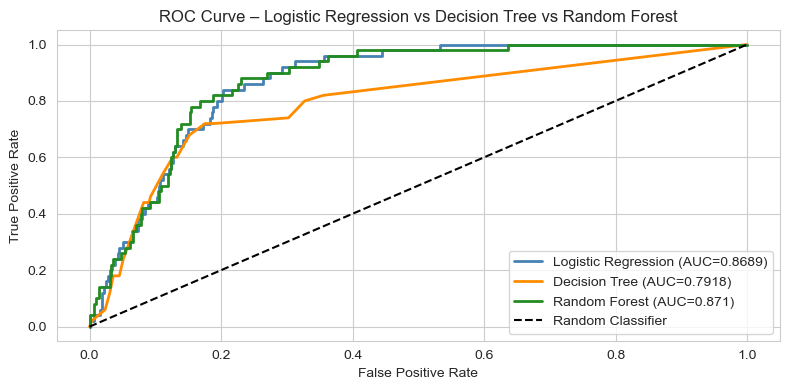

In [47]:
plt.figure(figsize=(8, 4))

for y_prob, label, color in [
    (y_prob_lr, f"Logistic Regression (AUC={lr_metrics['ROC-AUC']})", 'steelblue'),
    (y_prob_dt, f"Decision Tree (AUC={dt_metrics['ROC-AUC']})", 'darkorange'),
    (y_prob_rf, f"Random Forest (AUC={rf_metrics['ROC-AUC']})", 'forestgreen')
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=label, linewidth=2, color=color)

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve – Logistic Regression vs Decision Tree vs Random Forest')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

ROC-AUC summarizes each model's ability to rank stroke patients above non-stroke patients across every possible decision threshold, independent of the specific 0.5 cutoff used elsewhere in this notebook. The model whose curve sits closest to the top-left corner (and has the highest AUC) is doing the best job of separating the two classes overall, regardless of how the final classification threshold gets tuned later.

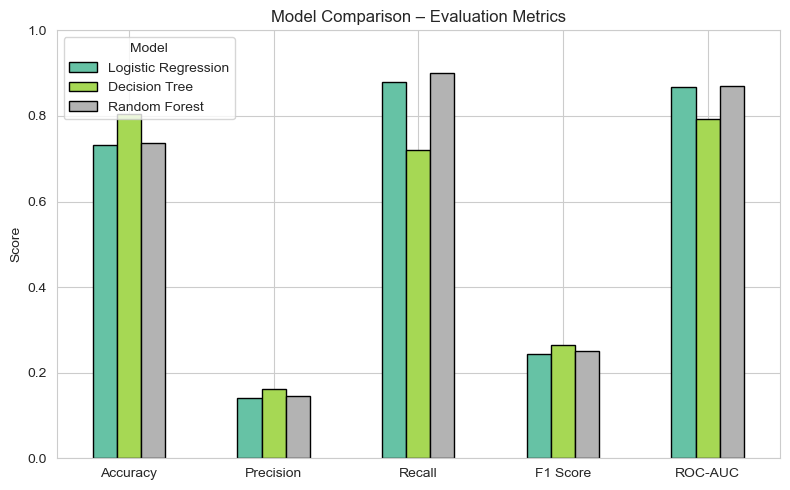

In [48]:
comparison_df.T.plot(kind='bar', figsize=(8,5), colormap='Set2', edgecolor='black')
plt.title('Model Comparison – Evaluation Metrics')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(title='Model')
plt.tight_layout()
plt.show()

This bar chart puts all five metrics for all three tuned models side by side for a final at-a-glance comparison.

In [49]:
print('FINAL MODEL COMPARISON')
print('=' * 50)
print(comparison_df.to_string())
print()

best_model_name = comparison_df['Recall'].idxmax()
print(f'Best model by Recall Score: {best_model_name}')
print()
print('Note: For stroke prediction, Recall is the most critical metric.')
print('A false negative (missing a stroke case) is more costly than a false positive.')
print('Prioritize the model with higher Recall for clinical use.')

FINAL MODEL COMPARISON
                     Accuracy  Precision  Recall  F1 Score  ROC-AUC
Model                                                              
Logistic Regression    0.7329     0.1415    0.88    0.2438   0.8689
Decision Tree          0.8053     0.1629    0.72    0.2657   0.7918
Random Forest          0.7378     0.1461    0.90    0.2514   0.8710

Best model by Recall Score: Random Forest

Note: For stroke prediction, Recall is the most critical metric.
A false negative (missing a stroke case) is more costly than a false positive.
Prioritize the model with higher Recall for clinical use.


## Conclusion & Recommendations

All three models were trained with `class_weight='balanced'` and tuned via stratified 5-fold cross-validation with F1 scoring, then evaluated on the same held-out test set. Across the comparison above, the choice of "best" model genuinely depends on what's being optimized for: the model with the highest **Recall** misses the fewest true stroke cases and is the better choice for an initial screening tool, while the model with the highest **Precision** or **F1** wastes fewer follow-up resources on false alarms. Given the stated goal of this notebook (flagging at-risk patients early, where a missed case is far more costly than an unnecessary check-up), recall should be weighted most heavily when making the final model choice for deployment.

A few honest limitations worth keeping in mind: the dataset has very few positive (stroke) examples in absolute terms, so test-set metrics, especially for the minority class, can shift noticeably with a different random seed or train/test split. Before any real clinical use, this work would need a larger and more recent dataset, external validation, and almost certainly a conversation with clinical stakeholders about where to set the probability threshold, since the current 0.5 cutoff is just a default rather than something tuned for this specific cost tradeoff.

In [50]:
from sklearn.preprocessing import LabelEncoder

# Check which columns are still object type
print(X_train.dtypes)

gender                object
age                    int64
hypertension           int64
heart_disease          int64
ever_married          object
work_type             object
Residence_type        object
avg_glucose_level    float64
bmi                  float64
smoking_status        object
dtype: object


In [51]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Encode all object/categorical columns
for col in X_train.select_dtypes(include='object').columns:
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col] = le.transform(X_test[col])

Model Accuracy: 0.95
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       972
           1       0.00      0.00      0.00        50

    accuracy                           0.95      1022
   macro avg       0.48      0.50      0.49      1022
weighted avg       0.90      0.95      0.93      1022



c:\Users\hp\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\hp\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\hp\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


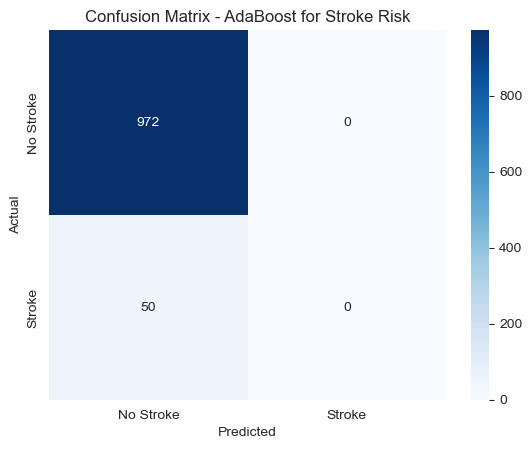

In [52]:
# Initialize and train AdaBoost model
from sklearn.ensemble import AdaBoostClassifier
base_model = DecisionTreeClassifier(max_depth=1)
# adaboost_model = AdaBoostClassifier(base_estimator=base_model, n_estimators=100, learning_rate=0.1, random_state=42)
adaboost_model = AdaBoostClassifier(estimator=base_model, n_estimators=100, learning_rate=0.1, random_state=42)
adaboost_model.fit(X_train, y_train)

# Make predictions
y_pred = adaboost_model.predict(X_test)

# Evaluate model performance
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2f}")

# Display classification report
print(classification_report(y_test, y_pred))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['No Stroke', 'Stroke'], yticklabels=['No Stroke', 'Stroke'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - AdaBoost for Stroke Risk')
plt.show()

Model Accuracy: 0.95
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       972
           1       0.50      0.02      0.04        50

    accuracy                           0.95      1022
   macro avg       0.73      0.51      0.51      1022
weighted avg       0.93      0.95      0.93      1022



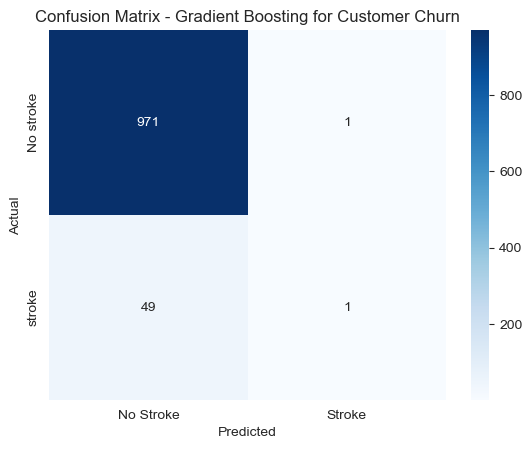

In [53]:
# Initialize and train Gradient Boosting model
from sklearn.ensemble import GradientBoostingClassifier
gb_model = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=42)
gb_model.fit(X_train, y_train)

# Make predictions
y_pred = gb_model.predict(X_test)

# Evaluate model performance
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2f}")

# Display classification report
print(classification_report(y_test, y_pred))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['No Stroke', 'Stroke'], yticklabels=['No stroke', 'stroke'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Gradient Boosting for Customer Churn')
plt.show()